# Exploratory Data Analysis (EDA)

El objetivo de este notebook es analizar el comportamiento histórico del mercado DOGE/USDT utilizando datos OHLCV obtenidos desde Binance, identificando patrones, distribuciones y propiedades relevantes para el posterior desarrollo de modelos predictivos y estrategias de trading algorítmico.

In [2]:
# ============================================================
# 03 - Exploratory Data Analysis (EDA)
# DOGE/USDT 5m dataset
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DATA_PATH = "../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["open_time", "close_time"]
)

df = df.sort_values("open_time").reset_index(drop=True)

print("Dataset loaded")
print("Shape:", df.shape)
print("Date range:", df["open_time"].min(), "->", df["open_time"].max())

display(df.head())

Dataset loaded
Shape: (723348, 43)
Date range: 2019-07-05 13:35:00 -> 2026-05-23 10:10:00


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,return_1,log_return_1,sma_20,ema_10,ema_50,ema_200,ema10_ema50_ratio,ema50_ema200_ratio,sma20_ema50_ratio,volatility_1h,zscore_close_1h,rsi_14,macd,macd_signal,macd_hist,bb_mid,bb_upper,bb_lower,bb_width,bb_percent,atr_14,future_close_1,up_1,future_close_3,return_3,up_3,future_close_6,return_6,up_6,future_close_12,return_12,up_12
0,2019-07-05 13:35:00,0.003815,0.003817,0.003785,0.003809,5726661.0,2019-07-05 13:39:59.999,21762.784020,91,2358281.0,8965.121690,0.008217,0.004368,0.003892,0.003838,0.004088,0.004266,0.938869,0.958317,0.951902,0.006961,-0.755034,49.819695,-0.000112,-0.000115,0.000003,0.003892,0.004138,0.003645,0.126550,0.332372,0.000057,0.003840,1,0.003800,-0.002389,0,0.003822,0.003413,1,0.003863,0.014072,1
1,2019-07-05 13:40:00,0.003812,0.003885,0.003812,0.003840,16701268.0,2019-07-05 13:44:59.999,64066.264668,158,10516524.0,40295.145114,-0.000182,0.008184,0.003866,0.003839,0.004079,0.004262,0.941197,0.956989,0.947923,0.007318,-0.111958,40.473840,-0.000105,-0.000113,0.000008,0.003866,0.003985,0.003747,0.061707,0.391960,0.000054,0.003840,0,0.003835,-0.001328,0,0.003836,-0.001198,0,0.003855,0.003776,1
2,2019-07-05 13:45:00,0.003842,0.003880,0.003831,0.003840,21970773.0,2019-07-05 13:49:59.999,84686.627401,137,4464170.0,17267.316184,-0.010339,-0.000182,0.003857,0.003839,0.004069,0.004258,0.943407,0.955733,0.947870,0.007037,-0.044888,40.809555,-0.000098,-0.000110,0.000012,0.003857,0.003952,0.003763,0.049034,0.408105,0.000053,0.003800,0,0.003831,-0.002344,0,0.003860,0.005287,1,0.003850,0.002787,1
3,2019-07-05 13:50:00,0.003835,0.003860,0.003800,0.003800,6436340.0,2019-07-05 13:54:59.999,24591.400060,90,1357970.0,5197.184336,0.009289,-0.010393,0.003854,0.003832,0.004059,0.004253,0.944117,0.954274,0.949473,0.007448,-0.704962,39.147040,-0.000095,-0.000107,0.000012,0.003854,0.003951,0.003756,0.050696,0.225739,0.000055,0.003835,1,0.003822,0.005816,1,0.003919,0.031316,1,0.003867,0.017632,1
4,2019-07-05 13:55:00,0.003820,0.003840,0.003806,0.003835,7182776.0,2019-07-05 13:59:59.999,27471.432703,75,4783851.0,18306.926861,-0.001199,0.009247,0.003849,0.003832,0.004050,0.004249,0.946314,0.953146,0.950371,0.007731,0.233418,41.493268,-0.000088,-0.000103,0.000015,0.003849,0.003940,0.003758,0.047413,0.425474,0.000055,0.003831,0,0.003836,0.000130,1,0.003864,0.007405,1,0.003841,0.001564,1


In [3]:
# ============================================================
# General overview
# ============================================================

print(df.info())

display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 723348 entries, 0 to 723347
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   open_time                     723348 non-null  datetime64[ns]
 1   open                          723348 non-null  float64       
 2   high                          723348 non-null  float64       
 3   low                           723348 non-null  float64       
 4   close                         723348 non-null  float64       
 5   volume                        723348 non-null  float64       
 6   close_time                    723348 non-null  datetime64[ns]
 7   quote_asset_volume            723348 non-null  float64       
 8   number_of_trades              723348 non-null  int64         
 9   taker_buy_base_asset_volume   723348 non-null  float64       
 10  taker_buy_quote_asset_volume  723348 non-null  float64       
 11  return_1     

,count,mean,min,25%,50%,75%,max,std
open_time,723348,2022-12-14 05:46:58.892153344,2019-07-05 13:35:00,2021-03-26 01:38:45,2022-12-14 13:02:30,2024-09-02 12:26:15,2026-05-23 10:10:00,NaN
open,723348.0,0.115585,0.001219,0.057783,0.09129,0.1677,0.73623,0.100819
high,723348.0,0.115866,0.001238,0.0579,0.09142,0.16802,0.73995,0.101174
low,723348.0,0.115298,0.001135,0.057633,0.09115,0.16735,0.72743,0.100453
close,723348.0,0.115586,0.001218,0.057783,0.09129,0.1677,0.73623,0.100819
volume,723348.0,6056203.622379,0.0,785939.5,1987237.5,4898750.75,2174740295.0,22372256.823813
close_time,723348,2022-12-14 05:51:58.889969664,2019-07-05 13:39:59.999000,2021-03-26 01:43:44.999000064,2022-12-14 13:07:29.999000064,2024-09-02 12:31:14.999000064,2026-05-23 10:14:59.999000,NaN
quote_asset_volume,723348.0,960786.948275,0.0,36627.730037,191032.921225,632953.071021,378267072.445506,4014587.680946
number_of_trades,723348.0,2142.179951,0.0,125.0,593.0,2069.0,385041.0,5342.120864
taker_buy_base_asset_volume,723348.0,3003087.212255,0.0,345511.5,948737.0,2424065.75,1087817541.0,11264252.416769


## Conclusiones – Visión general del dataset

El conjunto de datos final contiene más de 723.000 observaciones temporales correspondientes al par DOGE/USDT en intervalos de 5 minutos, cubriendo un rango temporal desde julio de 2019 hasta mayo de 2026.

El dataset presenta una estructura consistente y completa, sin valores nulos tras el proceso de limpieza y generación de variables derivadas, lo que permite su utilización directa en tareas de modelado y análisis temporal.

A nivel descriptivo, pueden observarse varias características relevantes:

- El mercado presenta una elevada dispersión en variables relacionadas con volumen y número de operaciones, reflejando periodos de actividad muy heterogéneos y episodios de alta volatilidad.

- Los retornos medios son extremadamente pequeños y cercanos a cero, como es habitual en series financieras de alta frecuencia, aunque acompañados de eventos extremos ocasionales.

- Los indicadores técnicos generados muestran distribuciones coherentes y estables, especialmente en variables como RSI, MACD y ratios entre medias móviles.

- Las variables objetivo (`up_1`, `up_3`, `up_6`, `up_12`) presentan una distribución relativamente equilibrada entre clases, lo que resulta favorable para futuros modelos de clasificación supervisada.

En conjunto, el dataset obtenido presenta características adecuadas para el desarrollo de modelos de machine learning aplicados al trading algorítmico y análisis predictivo de series temporales financieras.

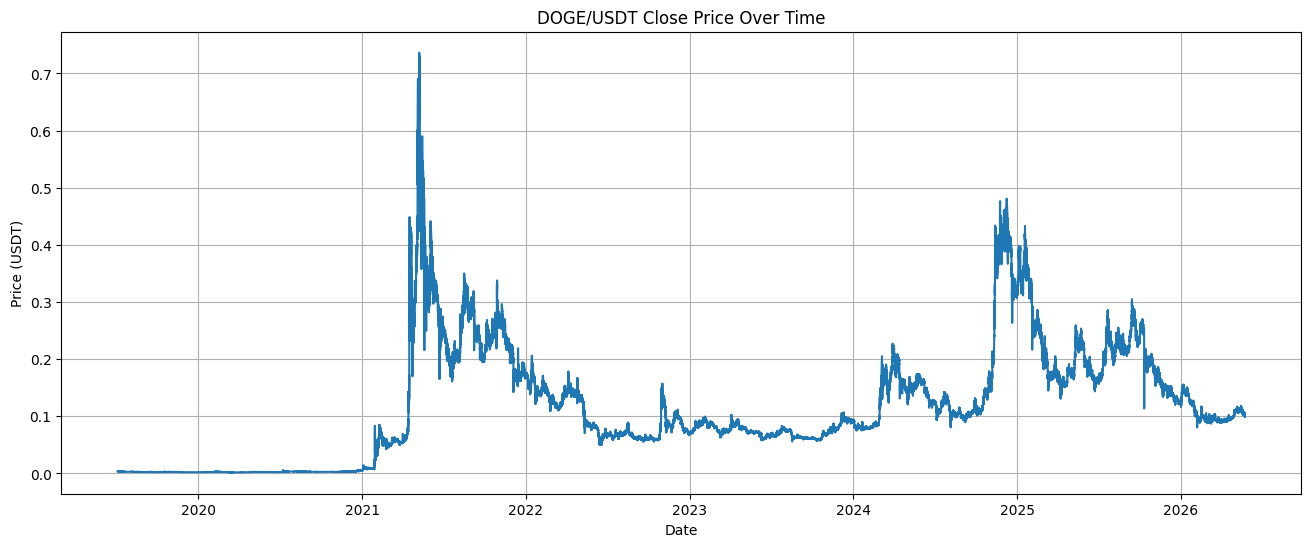

In [4]:
# ============================================================
# DOGE price evolution
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(df["open_time"], df["close"])

plt.title("DOGE/USDT Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USDT)")

plt.grid(True)

plt.show()

## Conclusiones – Evolución temporal del precio

La evolución histórica del precio de DOGE/USDT muestra claramente distintos regímenes de mercado, incluyendo periodos de estabilidad relativa, fases de crecimiento acelerado y episodios de elevada volatilidad.

Destacan especialmente los movimientos explosivos observados durante determinados ciclos alcistas del mercado de criptomonedas, caracterizados por fuertes incrementos de precio acompañados de aumentos significativos en la actividad de mercado.

Este comportamiento confirma la naturaleza altamente especulativa del activo y justifica la utilización de técnicas de modelado capaces de capturar dinámicas no lineales y cambios abruptos en las condiciones del mercado.

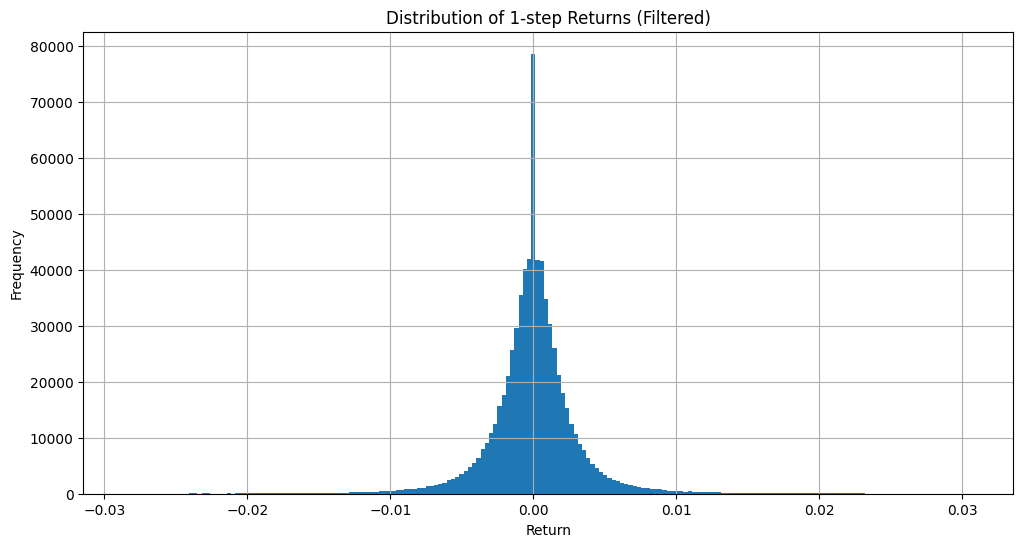

Original min/max: -0.4316399420550477 0.3084302729758541
Filtered min/max: -0.02852296734285439 0.030627411622994163
Skewness: 0.20858754079372543
Kurtosis: 387.9639959270505


In [10]:
# ============================================================
# Returns distribution (zoomed)
# ============================================================

returns = df["return_1"].dropna()

# Remove extreme outliers for visualization only
lower = returns.quantile(0.001)
upper = returns.quantile(0.999)

returns_filtered = returns[
    (returns >= lower) &
    (returns <= upper)
]

plt.figure(figsize=(12, 6))

plt.hist(
    returns_filtered,
    bins=200
)

plt.title("Distribution of 1-step Returns (Filtered)")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

print("Original min/max:", returns.min(), returns.max())
print("Filtered min/max:", lower, upper)
print("Skewness:", returns.skew())
print("Kurtosis:", returns.kurtosis())

## Conclusiones – Distribución de retornos

La distribución de retornos presenta una fuerte concentración de valores alrededor de cero, acompañada de colas significativamente más pesadas que las esperadas en una distribución normal.

La elevada kurtosis observada indica la presencia de eventos extremos relativamente frecuentes, un comportamiento característico de los mercados financieros y especialmente acentuado en activos de alta volatilidad como las criptomonedas.

Este comportamiento sugiere que el mercado presenta episodios abruptos de movimiento que podrían resultar relevantes para el entrenamiento de modelos predictivos y estrategias de trading.

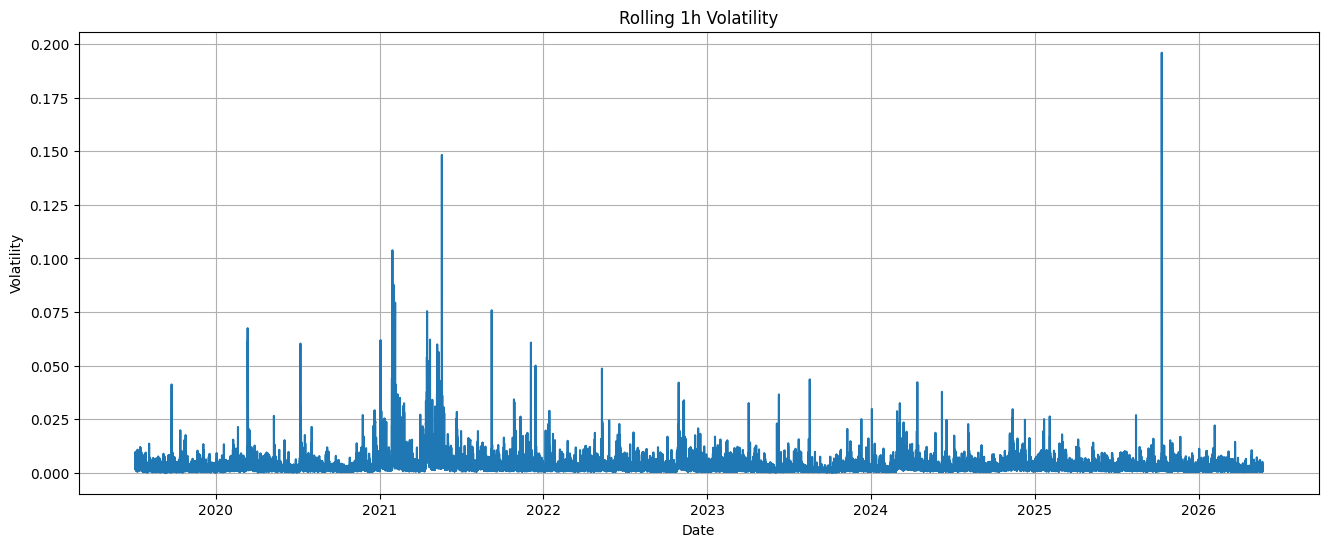

In [6]:
# ============================================================
# Volatility over time
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(df["open_time"], df["volatility_1h"])

plt.title("Rolling 1h Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)

plt.show()

## Conclusiones – Volatilidad temporal

La volatilidad presenta un comportamiento claramente no estacionario, alternando periodos de relativa estabilidad con episodios de fuerte variabilidad.

Este fenómeno, conocido como volatility clustering, es habitual en mercados financieros y resulta especialmente pronunciado en activos de alta especulación como las criptomonedas.

La existencia de distintos regímenes de volatilidad puede influir significativamente en el rendimiento de los modelos predictivos y en la gestión del riesgo dentro de estrategias de trading algorítmico.

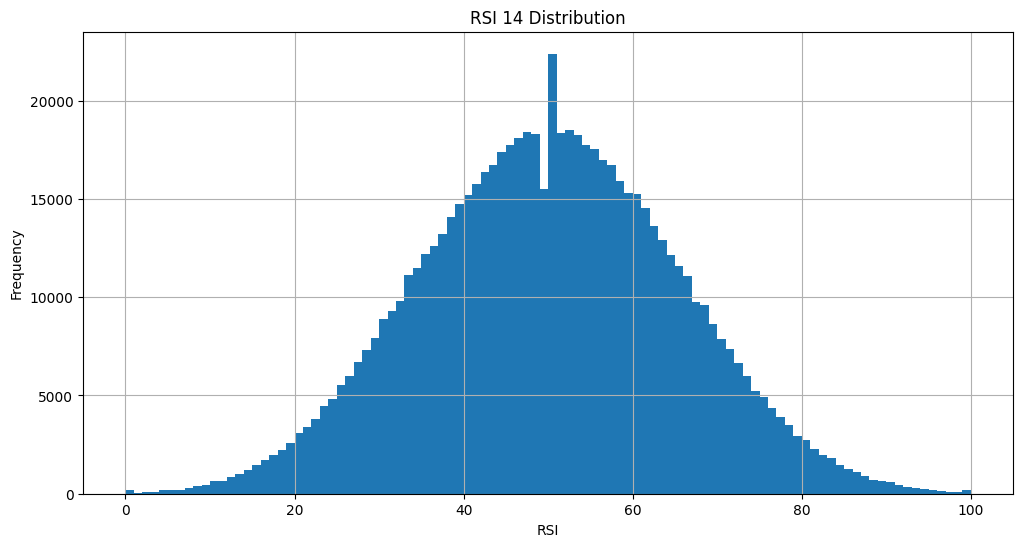

In [7]:
# ============================================================
# RSI distribution
# ============================================================

plt.figure(figsize=(12, 6))

plt.hist(
    df["rsi_14"],
    bins=100
)

plt.title("RSI 14 Distribution")
plt.xlabel("RSI")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Conclusiones – Distribución del RSI

La distribución del indicador RSI se concentra principalmente alrededor de valores intermedios cercanos a 50, reflejando un comportamiento relativamente equilibrado entre presión compradora y vendedora durante la mayor parte del periodo analizado.

No obstante, también se observan episodios extremos asociados a condiciones de sobrecompra y sobreventa, potencialmente relevantes para la identificación de señales de trading y cambios de tendencia.

In [8]:
# ============================================================
# Target balance
# ============================================================

target_cols = ["up_1", "up_3", "up_6", "up_12"]

for col in target_cols:

    counts = df[col].value_counts(normalize=True)

    print(f"\n{col}")
    print(counts)


up_1
up_1
0    0.530133
1    0.469867
Name: proportion, dtype: float64

up_3
up_3
0    0.509709
1    0.490291
Name: proportion, dtype: float64

up_6
up_6
0    0.505005
1    0.494995
Name: proportion, dtype: float64

up_12
up_12
0    0.502708
1    0.497292
Name: proportion, dtype: float64


## Conclusiones – Balance de clases objetivo

Las variables objetivo binarias presentan una distribución relativamente equilibrada entre clases, especialmente en horizontes temporales más amplios.

Este comportamiento resulta favorable para el entrenamiento de modelos supervisados de clasificación, ya que reduce la necesidad de aplicar técnicas agresivas de balanceo de clases.

Asimismo, puede observarse que los horizontes temporales más cortos presentan un ligero desequilibrio, probablemente asociado al ruido inherente al mercado en escalas de alta frecuencia.

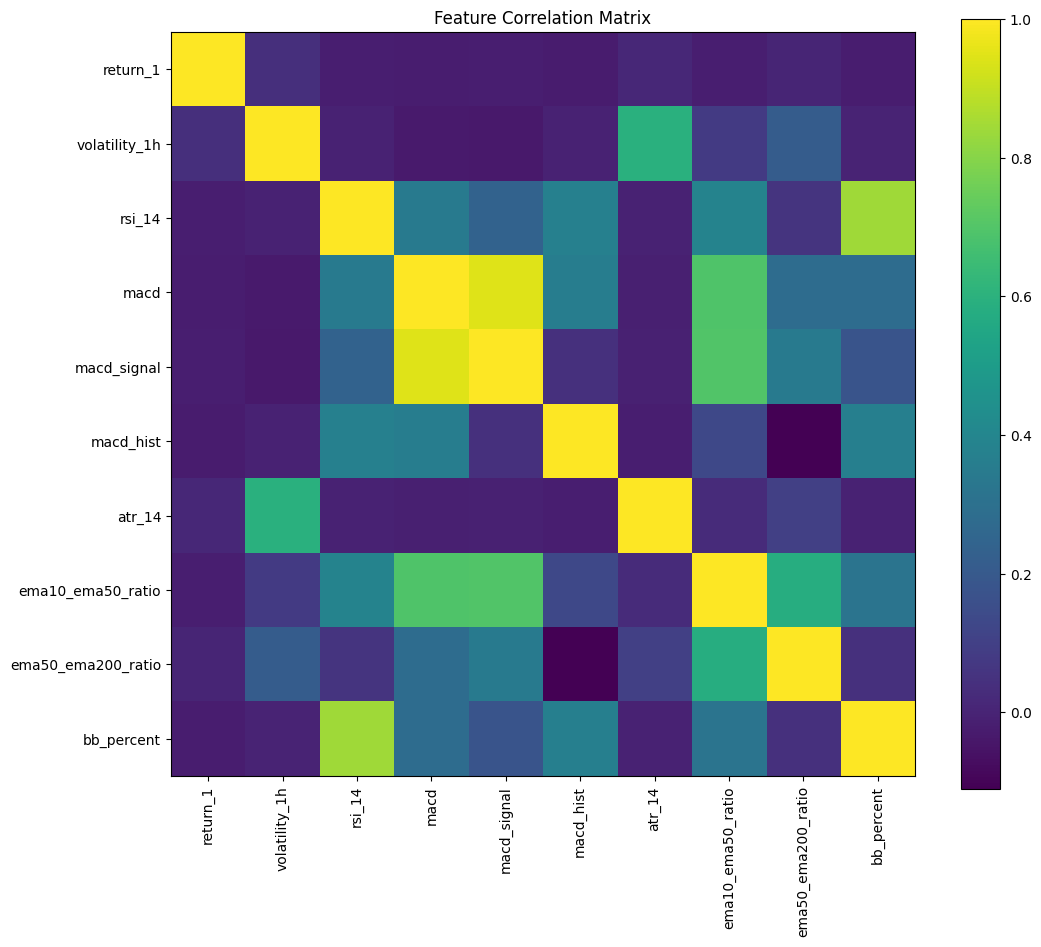

In [9]:
# ============================================================
# Correlation matrix
# ============================================================

feature_cols = [
    "return_1",
    "volatility_1h",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_hist",
    "atr_14",
    "ema10_ema50_ratio",
    "ema50_ema200_ratio",
    "bb_percent"
]

corr = df[feature_cols].corr()

plt.figure(figsize=(12, 10))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.show()

## Conclusiones – Correlación entre variables

La matriz de correlación muestra relaciones significativas entre algunos indicadores técnicos derivados de metodologías similares, especialmente entre variables basadas en medias móviles y componentes del MACD.

Esto sugiere la existencia de cierta redundancia parcial entre características, aspecto que podría ser relevante en fases posteriores de selección de variables o reducción de dimensionalidad.

Al mismo tiempo, otras variables presentan correlaciones moderadas o bajas, lo que indica que el conjunto de características conserva información diversa potencialmente útil para los modelos predictivos.